<a href="https://colab.research.google.com/github/abdullaawad/Medical-Insurance-Project/blob/main/Medical_Insurance_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle --quiet

In [2]:
from google.colab import files
files.upload()  # upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"abdullahismailawad","key":"5b68d42de473795ac78850a555e69a2b"}'}

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

In [4]:
!kaggle datasets download rahulvyasm/medical-insurance-cost-prediction

Dataset URL: https://www.kaggle.com/datasets/rahulvyasm/medical-insurance-cost-prediction
License(s): MIT
100% 31.6k/31.6k [00:00<00:00, 39.5MB/s]



In [5]:
!unzip medical-insurance-cost-prediction.zip

Archive:  medical-insurance-cost-prediction.zip
  inflating: medical_insurance.csv   


# **Problem Statement:**

## What are the primary factors influencing medical expenses?



## How accurate are machine learning models in predicting medical expenses?



## In what ways can machine learning models enhance the efficiency and profitability of health insurance companies?

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [7]:
df = pd.read_csv('/content/medical-insurance-cost-prediction.zip')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [9]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


## **What are the primary factors influencing medical expenses?**

## **Age:**

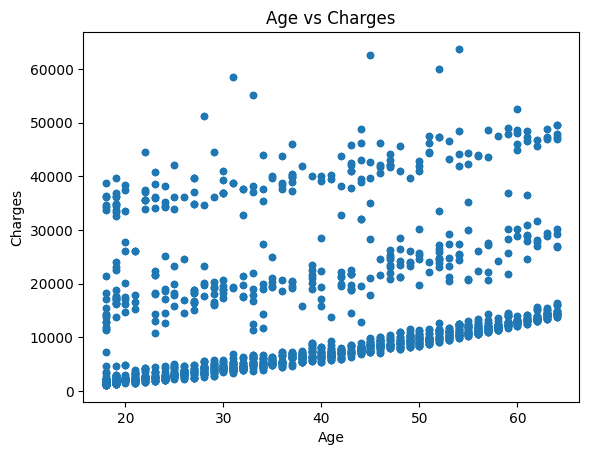

In [11]:
df.plot(x='age', y='charges', kind='scatter')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Age vs Charges')
plt.show()

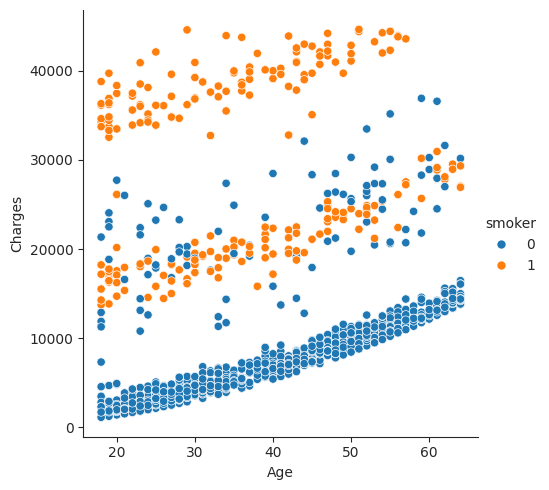

In [64]:
sns.set_style('ticks')
scatter_plot = sns.relplot(x='age', y='charges', data=df, kind='scatter', hue='smoker')
scatter_plot.set_axis_labels('Age', 'Charges')
plt.show()

# **Outlier detection & removal:**

In [13]:
age_outliers = px.box(df, x='age')
age_outliers.show()

In [15]:
bmi_outliers = px.box(df, x='bmi')
bmi_outliers.show()

In [16]:
df.drop(df[df['bmi'] > 47.52].index, inplace=True)

In [17]:
charges_outliers = px.box(df, x='charges')
charges_outliers.show()

In [18]:
df.drop(df[df['charges'] > 45000].index, inplace=True)

## **Sex**

In [14]:
sex_distribution = px.histogram(df, x='sex', y = 'charges')
sex_distribution

In [19]:
sex_count = df['sex'].value_counts()
sex_count

,count
sex,
male,1348
female,1332


In [20]:
avg_charges_per_region = df.groupby('region')['charges'].mean()
avg_charges_per_region

,charges
region,
northeast,12821.832098
northwest,11661.210716
southeast,13036.263472
southwest,11181.171772


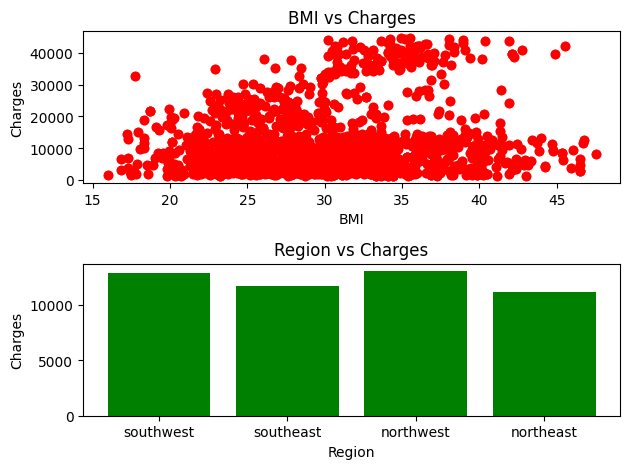

In [21]:
fig, ax = plt.subplots(2, 1)

ax[0].scatter(df['bmi'], df['charges'], color='r')
ax[0].set_xlabel('BMI')
ax[0].set_ylabel('Charges')
ax[0].set_title('BMI vs Charges')

ax[1].bar(df['region'].unique(), avg_charges_per_region, color='g')
ax[1].set_xlabel('Region')
ax[1].set_ylabel('Charges')
ax[1].set_title('Region vs Charges')

plt.tight_layout()
plt.show()

In [22]:
avg_charges_per_child = df.groupby('children')['charges'].mean()
avg_charges_per_child

,charges
children,
0,11414.575366
1,11750.660147
2,13795.801230
3,13798.532219
4,13550.983876
5,8706.036629


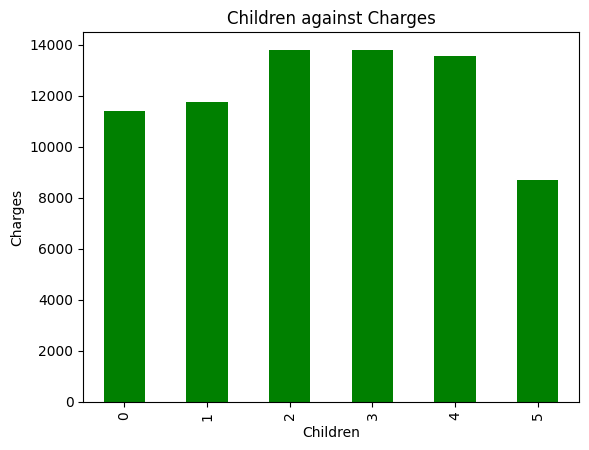

In [23]:
avg_charges_per_child.plot(kind='bar', color='g')
plt.xlabel('Children')
plt.ylabel('Charges')
plt.title('Children against Charges')
plt.show()

# **Implementing Machine Learning Algorithms:**

In [24]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

label_encoder = preprocessing.LabelEncoder()
df['sex']= label_encoder.fit_transform(df['sex'])

df['smoker']= label_encoder.fit_transform(df['smoker'])

df['region']= label_encoder.fit_transform(df['region'])

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=20, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,2680.0,38.671642,13.934297,18.0000,26.00000,39.000000,51.000000,64.0000
sex,2680.0,0.502985,0.500084,0.0000,0.00000,1.000000,1.000000,1.0000
bmi,2680.0,30.407056,5.917467,15.9600,26.03000,30.170000,34.337500,47.5200
children,2680.0,1.097761,1.218923,0.0000,0.00000,1.000000,2.000000,5.0000
smoker,2680.0,0.179851,0.384135,0.0000,0.00000,0.000000,0.000000,1.0000
region,2680.0,1.525373,1.107893,0.0000,1.00000,2.000000,2.000000,3.0000
charges,2680.0,12190.230200,10561.271987,1121.8739,4569.60765,8983.171925,14475.588787,44641.1974


In [26]:
print('Whole Data Shape', df.shape)
print('Training Data Shape', X_train.shape)
print('Testing Data Shape', X_test.shape)

Whole Data Shape (2680, 7)
Training Data Shape (1340, 6)
Testing Data Shape (1340, 6)


# **k-NN:**

In [27]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_knn = KNeighborsRegressor()
model_knn.fit(X_train, y_train)

y_pred = model_knn.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2_knn = r2_score(y_test, y_pred)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2_knn)

Mean Absolute Error: 2405.8755904094032
Mean Squared Error: 16502578.254578805
R-squared: 0.8519932825510903


In [28]:
acc=('{0:.2f}'.format(r2_knn))
print("Accuracy of k-Nearest Neighbours Model: ", acc, "%.")

Accuracy of k-Nearest Neighbours Model:  0.85 %.


In [29]:
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df2 = pd.DataFrame(data)


df2["Predicted Medical Insurance Charge"] = model_knn.predict(df2)
df2.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but KNeighborsRegressor was fitted without feature names



,age,sex,bmi,children,smoker,region,Predicted Medical Insurance Charge
0,56.0,1,29,3,0,2,13953.71601


# **Random Forest Regressor:**

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)

y_pred2 = model_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred2)
r2_rf = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R-squared:', r2_rf)

Mean Squared Error: 3087890.439167873
R-squared: 0.8519932825510903


In [32]:
accuracy_rf = ('{0:.2f}'.format(r2_rf))
print('Accuracy of the Random Forest Model: ', accuracy_rf, '%.')

Accuracy of the Random Forest Model:  0.85 %.


# **Decision Tree:**

In [33]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_dt = DecisionTreeRegressor()
model_dt.fit(X_train, y_train)

y_pred3 = model_dt.predict(X_test)

mae = mean_absolute_error(y_test, y_pred3)
mse = mean_squared_error(y_test, y_pred3)
r2 = r2_score(y_test, y_pred3)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)

Mean Absolute Error: 23.613874179104474
Mean Squared Error: 195027.10685753968
R-squared: 0.9982508598684249


In [34]:
print("The full Regression Decision Tree Levels: ", model_dt.tree_.max_depth)

The full Regression Decision Tree Levels:  20


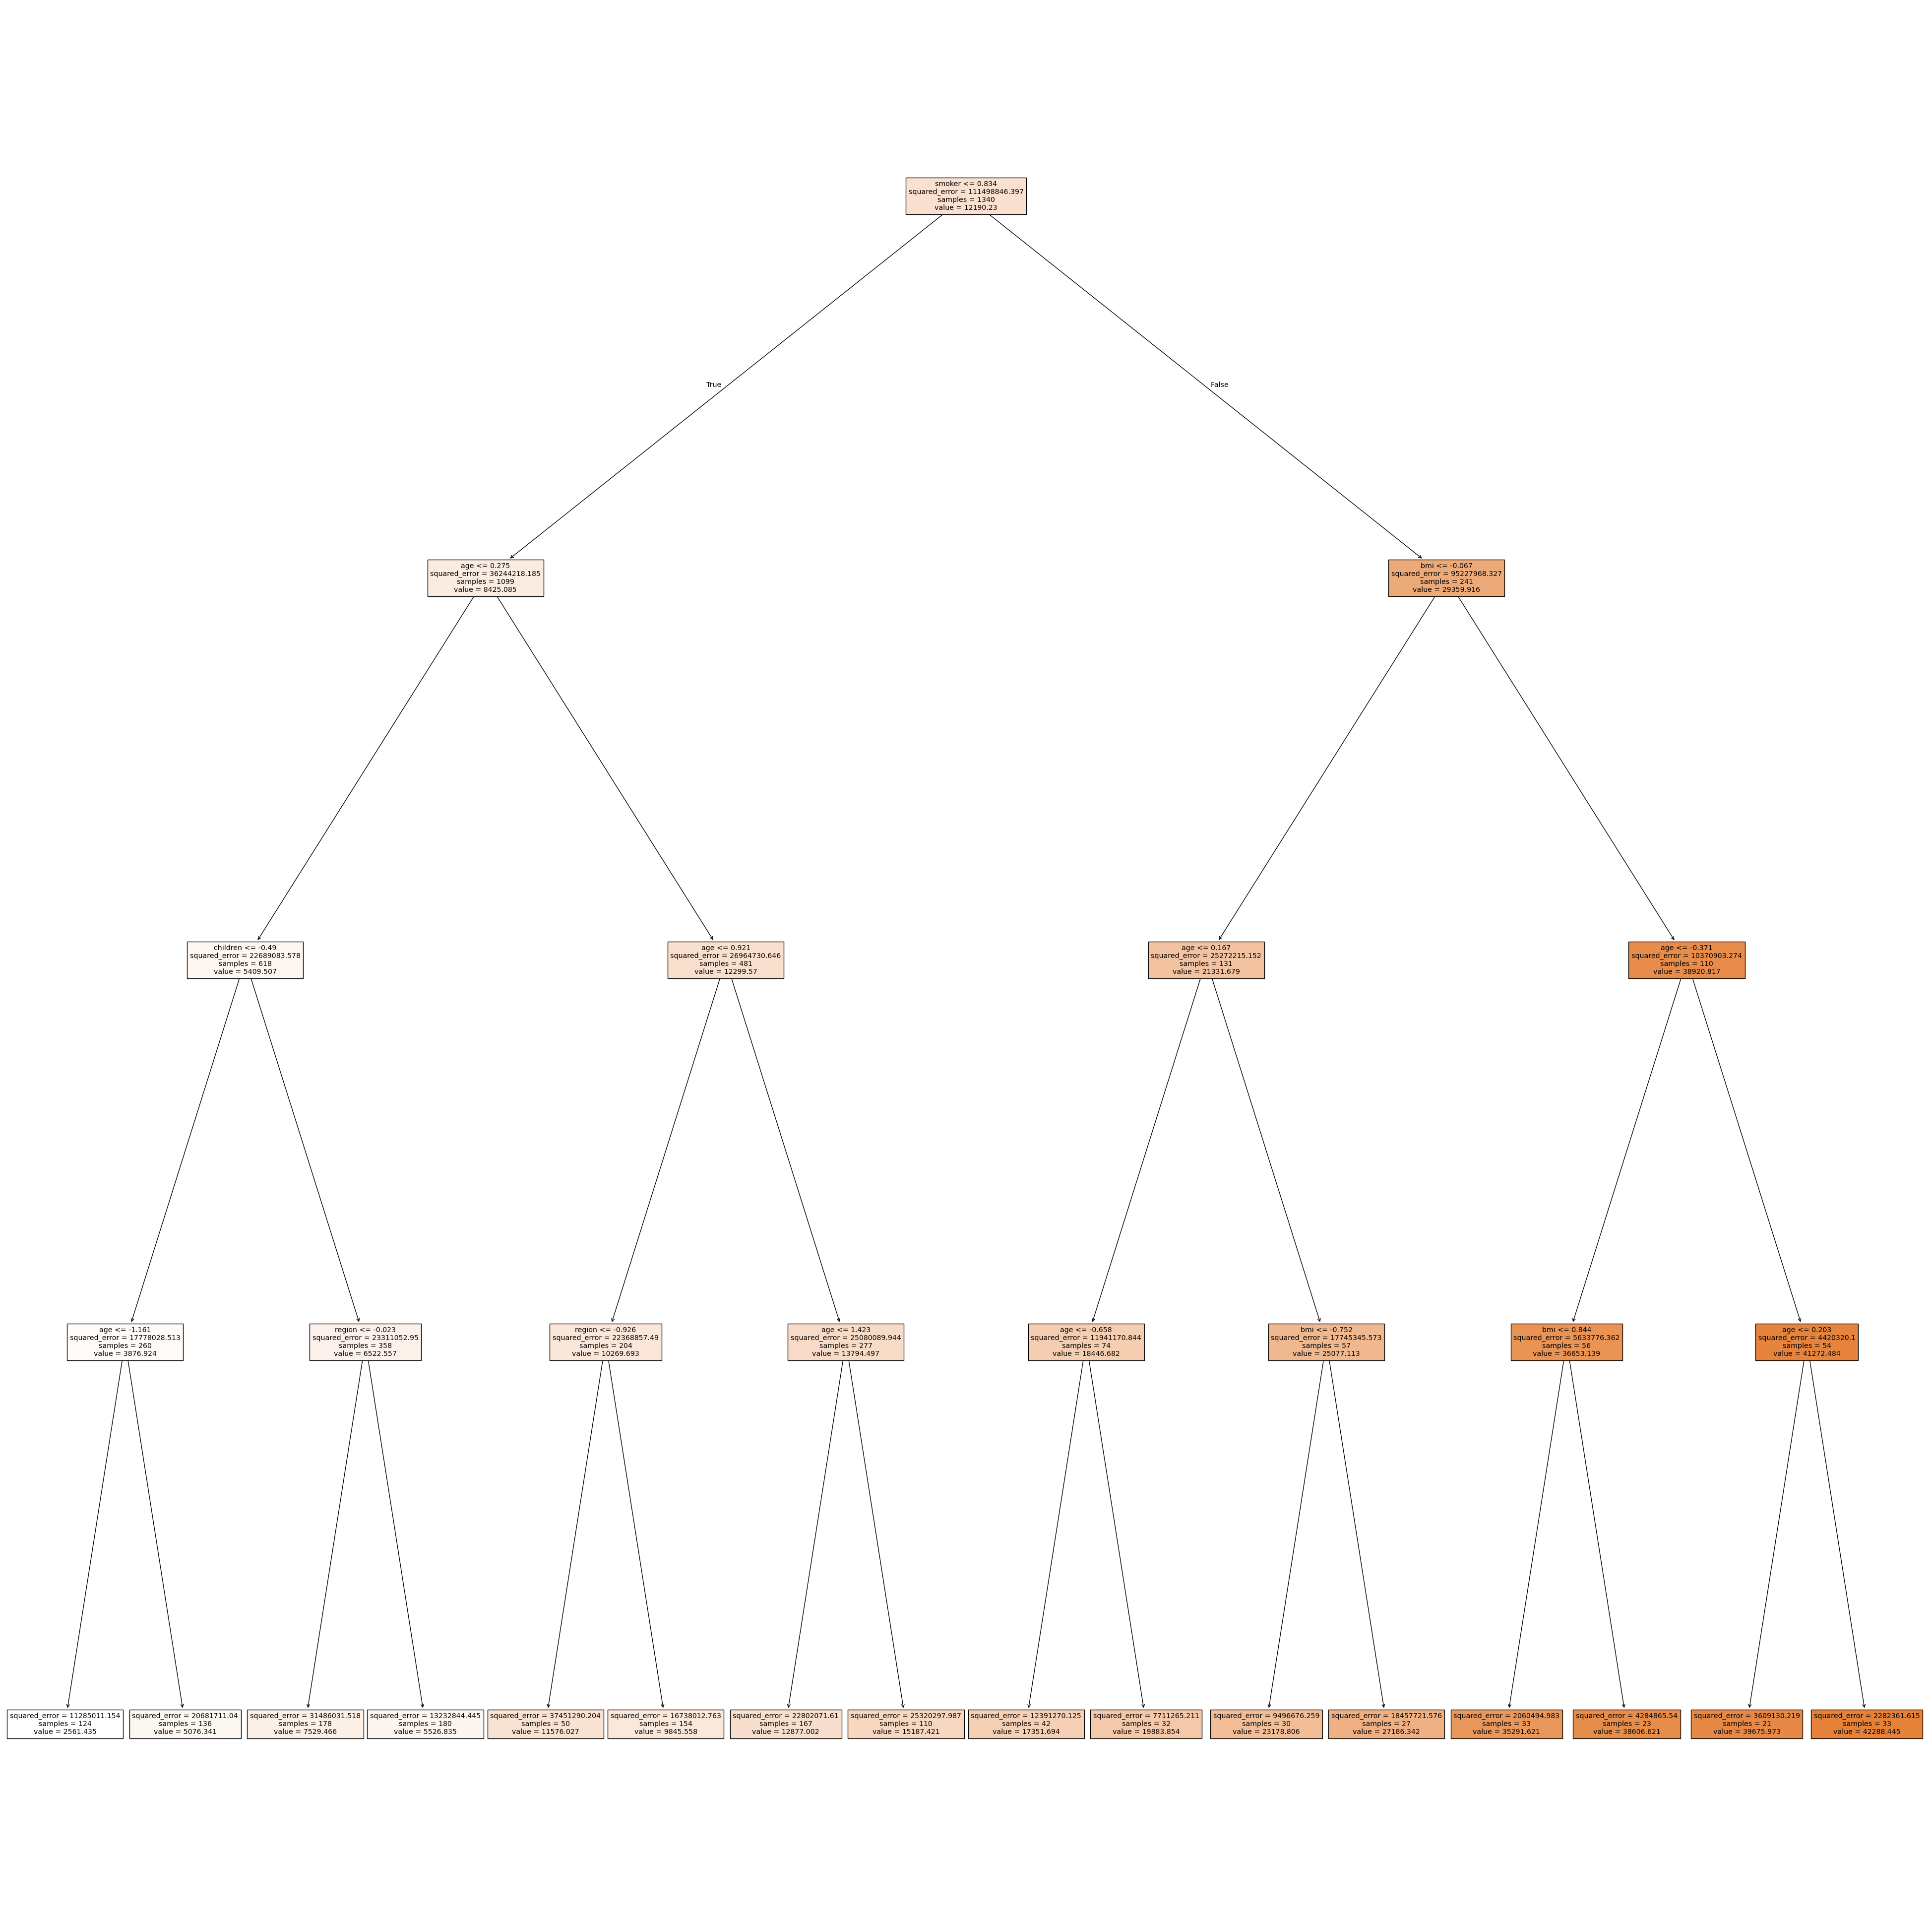

In [35]:
from sklearn.tree import plot_tree
pruned_regressor = DecisionTreeRegressor(max_depth=4)
pruned_regressor.fit(X_train, y_train)


y_pred_pruned = pruned_regressor.predict(X_test)


pruned_Tree_model = plt.figure(figsize=(50,50))
pruned_Tree_model_Graph = plot_tree(pruned_regressor, feature_names=list(X.columns), filled=True)


pruned_Tree_model.savefig("pruned_reg_decision_tree.png")

In [36]:
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df2 = pd.DataFrame(data)


df2["Predicted Medical Insurance Charge"] = pruned_regressor.predict(df2)
df2.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but DecisionTreeRegressor was fitted without feature names



,age,sex,bmi,children,smoker,region,Predicted Medical Insurance Charge
0,56.0,1,29,3,0,2,15187.421285


# **XGBoost:**

In [37]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

y_pred4 = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred4)
mse = mean_squared_error(y_test, y_pred4)
r2 = r2_score(y_test, y_pred4)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)

Mean Absolute Error: 560.5938646924674
Mean Squared Error: 1078599.4469097685
R-squared: 0.9903263622740265


### **XGBoost GridSearchCV Hyperparameter Tuning:**

In [38]:
params_xgb = {
    'n_estimators' : [100, 200, 300],
    'max_depth' : [3, 6, 9],
    'learning_rate' : [0.01, 0.1, 0.2],
    'gamma' : [0, 0.1, 0.2]
}

In [39]:
from sklearn.model_selection import GridSearchCV
xgb_gs = GridSearchCV(xgb_model, params_xgb, cv=5, n_jobs=-1)
xgb_gs.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 6, 9],
                         'n_estimators': [100, 200, 300]})

In [40]:
print(xgb_gs.best_estimator_)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [41]:
xgb_gs.best_estimator_.fit(X_train, y_train)
y_pred5 = xgb_gs.best_estimator_.predict(X_test)

mae = mean_absolute_error(y_test, y_pred5)
mse = mean_squared_error(y_test, y_pred5)
r2 = r2_score(y_test, y_pred5)

print('Mean Absolute Error:', mae)
print('Mean Squared Error:', mse)
print('R-squared:', r2)

Mean Absolute Error: 2479.024095597901
Mean Squared Error: 18323784.150632158
R-squared: 0.8356594283911399


In [42]:
# Prediction with pre-tuned XGBoost model
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df3 = pd.DataFrame(data)


df3["Predicted Medical Insurance Charge"] = xgb_model.predict(df3)
df3.head()

,age,sex,bmi,children,smoker,region,Predicted Medical Insurance Charge
0,56.0,1,29,3,0,2,26233.355469


In [43]:
# Prediction with GridSearchCV hypertuned parameters
data = []
data.append( {"age":56.0,
              "sex":1,
              "bmi":29,
              "children":3,
              "smoker":0,
              "region":2} )
df2 = pd.DataFrame(data)


df2["Predicted Medical Insurance Charge"] = xgb_gs.predict(df2)
df2.head()

,age,sex,bmi,children,smoker,region,Predicted Medical Insurance Charge
0,56.0,1,29,3,0,2,15746.595703
